# Business Sales Intelligence Dashboard

## Project Objective: -

The objective of this project is to analyze Superstore sales data using Python and Pandas to identify sales trends, profitable products, customer segments, regional performance, shipping patterns, and business opportunities.

The project concludes with business recommendations supported by data.

## Business Questions: -

This project aims to answer the following questions in the order of analysis:

1. Which product category generates the highest sales revenue?
2. Which specific product generates the highest sales revenue?
3. Which category earns the highest profit?
4. Which product causes the highest loss?
5. Which category receives the highest average discount?
6. Does higher discount reduce profit?
7. Which region has the lowest average profit?
8. Which customer segment generates the highest total sales?
9. Which customer segment generates the highest total profit?
10. Which shipping mode is used the most?

## Tools Used

- Python
- Pandas
- Google Colab

## Dataset

This project uses the Superstore Sales dataset containing 9,994 retail transactions.

The dataset includes information about:

- Products
- Customers
- Sales
- Profit
- Discounts
- Regions
- Shipping
- Dates

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Superstore.csv", encoding='latin1')

# SECTION 1 : Dataset Understanding

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.shape

(9994, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# SECTION 2 : Sales Analysis

## Business Question 1


### Which Product Category Generates the Highest Sales Revenue?

In [ ]:
print(df.groupby("Category")["Sales"].sum().idxmax())

Technology


## Business Question 2

### Which Product Generates the Highest Sales Revenue?

In [ ]:
print(df.groupby("Product Name")["Sales"].sum().idxmax())

Canon imageCLASS 2200 Advanced Copier


##Top 10 Products by Sales: -

In [ ]:
print(df.groupby(["Product Name","Category"])["Sales"].sum().sort_values(ascending=False).head(10))

Product Name                                                                 Category       
Canon imageCLASS 2200 Advanced Copier                                        Technology         61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind  Office Supplies    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                        Technology         22638.480
HON 5400 Series Task Chairs for Big and Tall                                 Furniture          21870.576
GBC DocuBind TL300 Electric Binding System                                   Office Supplies    19823.479
GBC Ibimaster 500 Manual ProClick Binding System                             Office Supplies    19024.500
Hewlett Packard LaserJet 3310 Copier                                         Technology         18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                    Technology         18374.895
GBC DocuBind P400 Electric Binding System                  

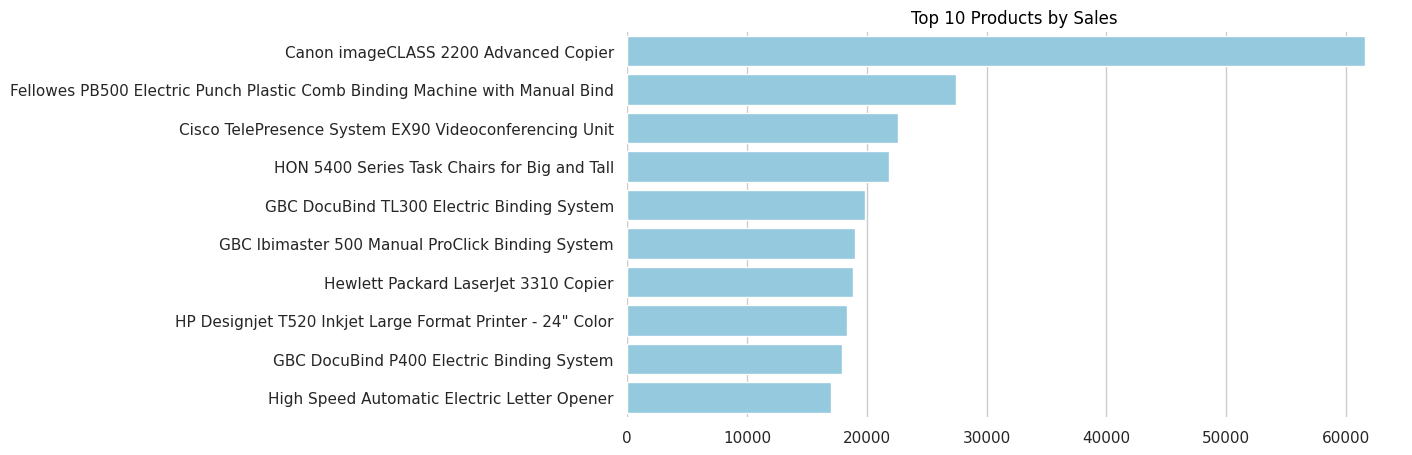

In [ ]:
# Data preparation
top_10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

# Ultra-simple Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_products, y='Product Name', x='Sales', color='skyblue')

# Remove all non-essential elements
sns.despine(left=True, bottom=True)
plt.tick_params(left=False, bottom=False)
plt.title('Top 10 Products by Sales', fontsize=12, loc='center', color='black')
plt.xlabel('')
plt.ylabel('')

plt.show()

## Average Sales per Category

In [ ]:
print(df.groupby("Category")["Sales"].mean())

Category
Furniture          349.834887
Office Supplies    119.324101
Technology         452.709276
Name: Sales, dtype: float64


### Visualizing Sales by Category

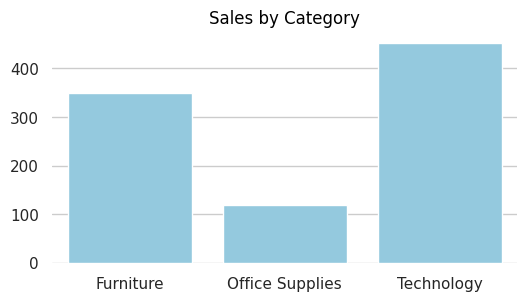

In [ ]:
# Data
category_sales = df.groupby('Category')['Sales'].mean().reset_index()

# Ultra-simple Plot
plt.figure(figsize=(6, 3))
sns.barplot(data=category_sales, x='Category', y='Sales', color='skyblue')

# Remove all non-essential elements
sns.despine(left=True, bottom=True)
plt.tick_params(left=False, bottom=False)
plt.title('Sales by Category', fontsize=12, loc='center', color='black')
plt.xlabel('')
plt.ylabel('')

plt.show()

# SECTION 3 : Profit Analysis

## Business Question 3

### Which Category earns the highest Profit?

In [ ]:
print(df.groupby("Category")["Profit"].sum().idxmax())

Technology


## Business Question 4

### Which Product causes the highest Loss?

In [ ]:
print(df.groupby("Product Name")["Profit"].sum().idxmax())

Canon imageCLASS 2200 Advanced Copier


## Top 10 Most Profitable Products

In [ ]:
print(df.groupby(["Product Name","Category"])["Profit"].sum().sort_values(ascending=False).head(10))

Product Name                                                                 Category       
Canon imageCLASS 2200 Advanced Copier                                        Technology         25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind  Office Supplies     7753.0390
Hewlett Packard LaserJet 3310 Copier                                         Technology          6983.8836
Canon PC1060 Personal Laser Copier                                           Technology          4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                    Technology          4094.9766
Ativa V4110MDD Micro-Cut Shredder                                            Technology          3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                             Technology          3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                   Technology          3696.2820
Ibico EPK-21 Electric Binding System               

### Visualizing Profit by Category

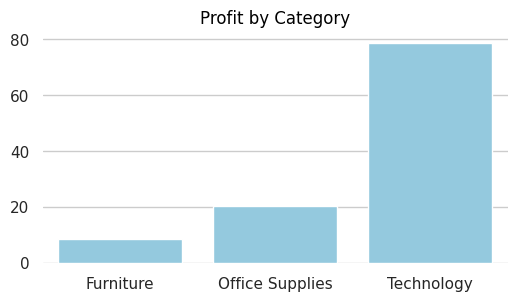

In [ ]:
# Data
category_profit = df.groupby('Category')['Profit'].mean().reset_index()

# Ultra-simple Plot (Matching Sales Style)
plt.figure(figsize=(6, 3))
sns.barplot(data=category_profit, x='Category', y='Profit', color='skyblue')

# Remove all non-essential elements
sns.despine(left=True, bottom=True)
plt.tick_params(left=False, bottom=False)
plt.title('Profit by Category', fontsize=12, loc='center', color='black')
plt.xlabel('')
plt.ylabel('')

plt.show()

## Profit by Sub-Category

In [ ]:
print(df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(3))

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Name: Profit, dtype: float64


## Loss by Sub-Category

In [ ]:
print(df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=True).head(3))

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


# SECTION 4 : Discount Analysis

## Average Discount by Category: -

In [ ]:
print(df.groupby("Category")["Discount"].mean().sort_values(ascending=True))

Category
Technology         0.132323
Office Supplies    0.157285
Furniture          0.173923
Name: Discount, dtype: float64


## Business Question 5

### Which Category receives the highest Discount?

In [ ]:
print(df.groupby("Category")["Discount"].sum().idxmax())

Office Supplies


## Business Question 6

### Does higher Discount reduce Profit?

In [ ]:
print(df.groupby("Discount")["Profit"].sum())

Discount
0.00    320987.6032
0.10      9029.1770
0.15      1418.9915
0.20     90337.3060
0.30    -10369.2774
0.32     -2391.1377
0.40    -23057.0504
0.45     -2493.1111
0.50    -20506.4281
0.60     -5944.6552
0.70    -40075.3569
0.80    -30539.0392
Name: Profit, dtype: float64


Yes!! it does.

# SECTION 5 : Regional Analysis

## Highest Sales Region

In [ ]:
print(df.groupby("Region")["Sales"].sum().idxmax())

West


### Visualizing Sales by Region

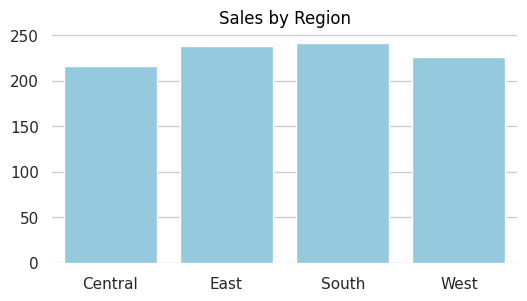

In [ ]:
# Data
region_sales = df.groupby('Region')['Sales'].mean().reset_index()

# Ultra-simple Plot (Matching established style)
plt.figure(figsize=(6, 3))
sns.barplot(data=region_sales, x='Region', y='Sales', color='skyblue')

# Remove all non-essential elements
sns.despine(left=True, bottom=True)
plt.tick_params(left=False, bottom=False)
plt.title('Sales by Region', fontsize=12, loc='center', color='black')
plt.xlabel('')
plt.ylabel('')

plt.show()

## Highest Profit Region

In [ ]:
print(df.groupby("Region")["Profit"].sum().idxmax())

West


## Lowest Profit Region

In [ ]:
print(df.groupby("Region")["Profit"].sum().idxmin())

Central


## Average Sales per Region

In [ ]:
print(df.groupby("Region")["Sales"].mean())

Region
Central    215.772661
East       238.336110
South      241.803645
West       226.493233
Name: Sales, dtype: float64


## Category with highest Sales in every Region

In [ ]:
print(df.groupby(["Region", "Category"])["Sales"].sum().groupby(level=0, group_keys=False).nlargest(1))

Region   Category  
Central  Technology    170416.3120
East     Technology    264973.9810
South    Technology    148771.9080
West     Furniture     252612.7435
Name: Sales, dtype: float64


## Average Sales of each Category in every Region

In [ ]:
print(df.groupby(["Region", "Category"])["Sales"].mean())

Region   Category       
Central  Furniture          340.534644
         Office Supplies    117.458801
         Technology         405.753124
East     Furniture          346.574383
         Office Supplies    120.044425
         Technology         495.278469
South    Furniture          353.309289
         Office Supplies    126.282727
         Technology         507.753952
West     Furniture          357.302325
         Office Supplies    116.422377
         Technology         420.687533
Name: Sales, dtype: float64


## Business Question 7

### Which Region has the lowest average Profit?

In [ ]:
print(df.groupby("Region")["Profit"].mean().idxmin())

Central


# SECTION 6 : Customer Segment Analysis

## Business Question 8

### Which Segment generates highest Sales?

In [ ]:
print(df.groupby("Segment")["Sales"].sum().idxmax())

Consumer


## Business Question 9

### Which Segment generates highest Profit?

In [ ]:
print(df.groupby("Segment")["Profit"].sum().idxmax())

Consumer


## Average Sales per Segment

In [ ]:
print(df.groupby("Segment")["Sales"].mean())

Segment
Consumer       223.733644
Corporate      233.823300
Home Office    240.972041
Name: Sales, dtype: float64


## Product Segment Analysis

In [ ]:
print(df.groupby('Segment').agg({'Sales': 'mean', 'Profit': 'sum'}).sort_values(by='Sales', ascending=False))

                  Sales       Profit
Segment                             
Home Office  240.972041   60298.6785
Corporate    233.823300   91979.1340
Consumer     223.733644  134119.2092


# SECTION 7 : Shipping Analysis

## Business Question 10

### Which Ship Mode is used the most?

In [ ]:
print(df["Ship Mode"].value_counts().idxmax())

Standard Class


## Average Profit by Ship Mode

In [ ]:
print(df.groupby("Ship Mode")["Profit"].mean())

Ship Mode
First Class       31.839948
Same Day          29.266591
Second Class      29.535545
Standard Class    27.494770
Name: Profit, dtype: float64


### Visualizing Ship Mode Usage

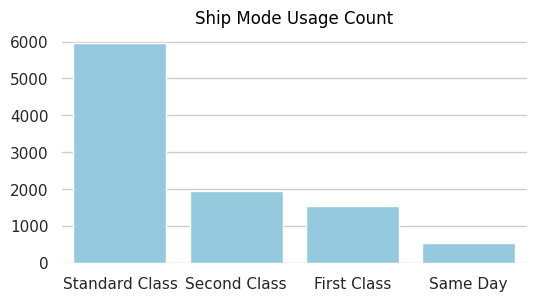

In [ ]:
# Data
ship_mode_counts = df['Ship Mode'].value_counts().reset_index()
ship_mode_counts.columns = ['Ship Mode', 'Count']

# Ultra-simple Plot
plt.figure(figsize=(6, 3))
sns.barplot(data=ship_mode_counts, x='Ship Mode', y='Count', color='skyblue')

# Remove all non-essential elements
sns.despine(left=True, bottom=True)
plt.tick_params(left=False, bottom=False)
plt.title('Ship Mode Usage Count', fontsize=12, loc='center', color='black')
plt.xlabel('')
plt.ylabel('')

plt.show()

## Average Sales by Ship Mode

In [ ]:
print(df.groupby("Ship Mode")["Sales"].mean())

Ship Mode
First Class       228.497024
Same Day          236.396179
Second Class      236.089239
Standard Class    227.583067
Name: Sales, dtype: float64


## Ship Mode Usage & Profit

In [ ]:
print(df.groupby('Ship Mode').agg({'Profit': ['count', 'sum', 'mean']}))

               Profit                        
                count          sum       mean
Ship Mode                                    
First Class      1538   48969.8399  31.839948
Same Day          543   15891.7589  29.266591
Second Class     1945   57446.6354  29.535545
Standard Class   5968  164088.7875  27.494770


# SECTION 8 : Time Analysis

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
# df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [ ]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()

## Sales by Year

In [ ]:
print(df.groupby("Year")["Sales"].sum())

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


## Profit by Year

In [ ]:
print(df.groupby("Year")["Profit"].sum())

Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64


## Sales by Month

In [ ]:
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

In [ ]:
print(df.groupby("Month")["Sales"].sum().reindex(month_order))

Month
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64


### Visualizing Sales by Month

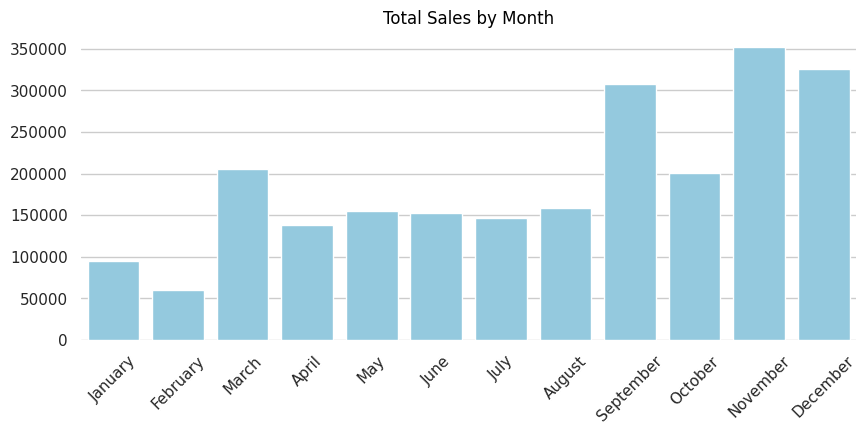

In [ ]:
# Data preparation
monthly_sales = df.groupby("Month")["Sales"].sum().reindex(month_order).reset_index()

# Ultra-simple Plot
plt.figure(figsize=(10, 4))
sns.barplot(data=monthly_sales, x='Month', y='Sales', color='skyblue')

# Remove all non-essential elements
sns.despine(left=True, bottom=True)
plt.tick_params(left=False, bottom=False)
plt.title('Total Sales by Month', fontsize=12, loc='center', color='black')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45)

plt.show()

## Month with highest Sales

In [ ]:
print(df.groupby("Month")["Sales"].sum().idxmax())

November


## Month with Lowest Sales

In [ ]:
print(df.groupby("Month")["Sales"].sum().idxmin())

February


# SECTION 9: Business Recommendations

#### **Observation 1**
> **Technology** contributes the highest sales and profit among all product categories.

#### **Interpretation**
> This suggests that technology products have strong customer demand and play a major role in the company's revenue.

#### **Recommendations**
>*   **Inventory Management:** Maintain sufficient inventory levels of technology products to meet consistent demand.
>*   **Marketing Focus:** Prioritize marketing campaigns and promotional activities on high-performing technology items.
>*   **Stock Optimization:** Implement rigorous monitoring to ensure popular products remain in stock at all times.

#### **Expected Impact**
>*   **Increased revenue**
>*   **Reduced stock-outs**
>*   **Higher customer satisfaction**

#### **Observation 2**
> **Furniture** consists of highest discount among all product categories.

#### **Interpretation**
> This shows the reason for furniture category to have such a low profit among other categories as well as company's revenue.

#### **Recommendations**
>*   **Marketing Focus:** Prioritize marketing the combinations of low-performing furniture items with the items of other product categories.
>*   **Discount Optimization:** Re-evaluate the discounts to ensure the increase in profit of high-performing furniture items.

#### **Expected Impact**
>*   **Increased revenue**
>*   **Maintain constant stock supply**
>*   **Higher customer satisfaction**

#### **Observation 3**
> **Central** region has lowest sales compared to other regions.

#### **Interpretation**
> This shows that either there is not enough marketing of the products or there is shortage of products in our shops in **Central** region, it can cause depletion in company's revenue .

#### **Recommendations**
>*   **Marketing Focus:** Prioritize marketing every Products near every shop or our company in **Central** region.
>*   **Maintain Adequate Stock:** Make sure that shops from **Central** region keeps a constant and proper supply of products in their warehouses.

#### **Expected Impact**
>*   **Increased revenue**
>*   **Maintain constant stock supply**

#### **Observation 4**
> **Tables** and **Bookcases** are causing the most losses even though they have high sales.

#### **Interpretation**
> This shows that these specific items are either priced too low or the costs for shipping and discounts are too high, causing the company to lose money on them.

#### **Recommendations**
>*   **Price Adjustment:** Increase the base price of Tables and Bookcases to make sure we aren't selling them at a loss.
>*   **Shipping Fees:** Add a shipping fee for these heavy items to help cover the high delivery costs.
>*   **Bundle Deals:** Only give discounts on these items when they are bought together with high-profit Technology products.

#### **Expected Impact**
>*   **Better profit margins**
>*   **Reduced losses on furniture**

#### **Observation 5**
> **Standard Class** is the most popular shipping method but brings in the lowest average profit.

#### **Interpretation**
> This shows that while most customers prefer the cheapest shipping, the profit margin is very small, making it risky if shipping costs go up.

#### **Recommendations**
>*   **Encourage Upgrades:** Offer small deals to get customers to choose 'Second Class' or 'First Class' shipping instead.
>*   **Logistics Deals:** Negotiate better rates with shipping companies for high-volume Standard Class orders to save money.

#### **Expected Impact**
>*   **Higher profit per order**
>*   **More efficient shipping costs**

#### **Observation 6**
> **Corporate** and **Home Office** customers spend more on average per order than regular Consumers.

#### **Interpretation**
> This shows that while we have more regular customers, business clients buy more expensive items or larger amounts at once, which is better for revenue.

#### **Recommendations**
>*   **B2B Support:** Create special accounts or paths for Corporate clients to make it easier for them to place large orders.
>*   **Targeted Ads:** Focus more ads on Home Office setups, showing them bundles of high-value equipment.

#### **Expected Impact**
>*   **Higher average sales per order**
>*   **Better sales efficiency**

# Conclusion

This analysis shows that **Technology** is our strongest area, while **Furniture** needs better pricing and discount management to stop losing money.

Since most customers use **Standard Class** shipping, finding ways to make it more efficient is key to increasing our profit.

We also saw that some regions perform much better than others, which gives us a clear idea of where to invest more in the future.

Overall, these data-driven insights give us a clear path to help the business grow and become more profitable.